In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)


In [2]:
# Cell 2: Load dataset
df = pd.read_csv("../Data/final_classification_ready_v2.csv")
print("Shape:", df.shape)
df.head()


Shape: (45155, 18)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,DEP_DEL15,OP_UNIQUE_CARRIER_ENC,ORIGIN_ENC,DEST_ENC,TIME_OF_DAY_ENC,TEMP_DIFF
0,4,1,2,6.53,9.33,168.0,1020.0,33.0,36.0,89.0,5.0,10.0,0.0,0,1,62,2,3.0
1,4,1,2,15.45,18.12,160.0,1020.0,33.0,45.0,63.0,10.0,10.0,1.0,0,1,62,0,12.0
2,4,1,2,7.33,15.32,299.0,2279.0,37.0,43.0,80.0,10.0,6.0,0.0,0,4,14,2,6.0
3,4,1,2,13.83,21.83,300.0,2279.0,41.0,49.0,74.0,10.0,6.0,0.0,0,4,14,1,8.0
4,4,1,2,22.00,6.00,300.0,2279.0,41.0,45.0,86.0,10.0,7.0,0.0,0,4,14,3,4.0


In [3]:
# Cell 3: Split features and target
X = df.drop(columns=["DEP_DEL15"])
y = df["DEP_DEL15"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (36124, 17) | Test: (9031, 17)


In [4]:
# Cell 4: Scale and balance with SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print("Trước SMOTE:", np.bincount(y_train))
print("Sau SMOTE :", np.bincount(y_train_bal))


Trước SMOTE: [31882  4242]
Sau SMOTE : [31882 31882]


C:\Users\PC\AppData\Local\Temp\ipykernel_16796\1983926009.py:9: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Trước SMOTE:", np.bincount(y_train))
C:\Users\PC\AppData\Local\Temp\ipykernel_16796\1983926009.py:10: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Sau SMOTE :", np.bincount(y_train_bal))


In [5]:
# Cell 5: Train LightGBM model
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

lgb_model = LGBMClassifier(
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=6,
    num_leaves=32,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,  # ⚖️ xử lý imbalance
    objective="binary"
)

lgb_model.fit(X_train_bal, y_train_bal)

# Predict
y_pred = lgb_model.predict(X_test_scaled)
y_prob = lgb_model.predict_proba(X_test_scaled)[:, 1]


[LightGBM] [Info] Number of positive: 31882, number of negative: 31882
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3920
[LightGBM] [Info] Number of data points in the train set: 63764, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
# Cell 6: Evaluate model
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("📊 LightGBM (Feature Eng + SMOTE) Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")


📊 LightGBM (Feature Eng + SMOTE) Performance:
Accuracy : 0.6533
Precision: 0.2025
Recall   : 0.6651
F1-score : 0.3105
ROC-AUC  : 0.7037


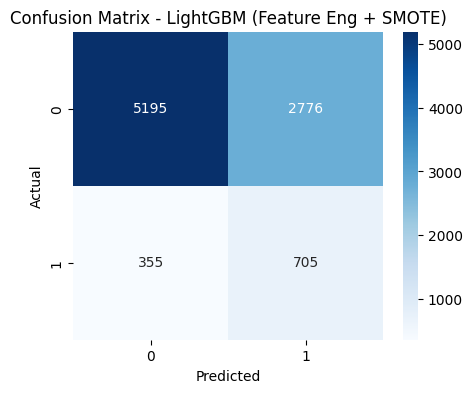

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LightGBM (Feature Eng + SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


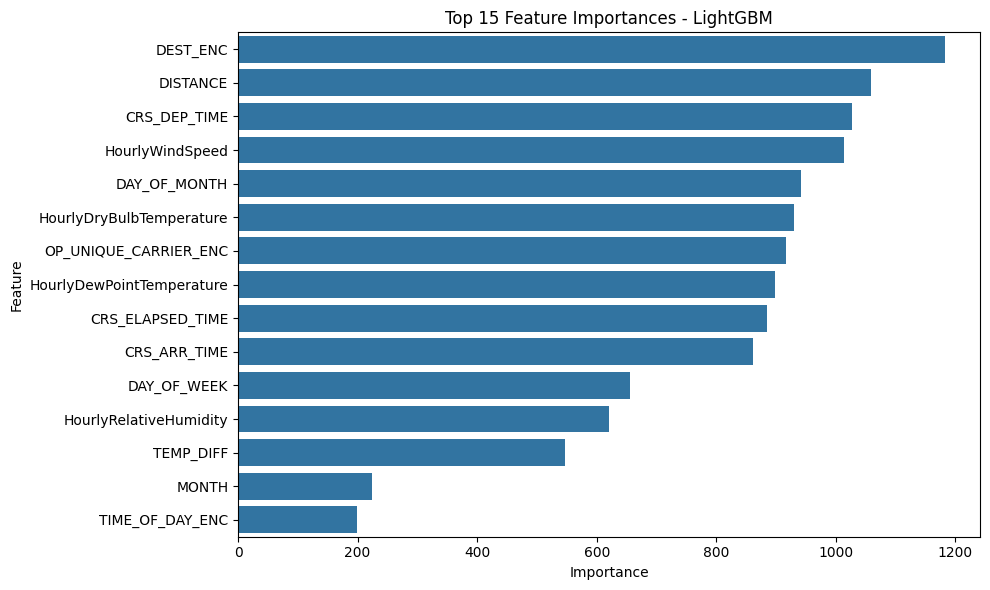

In [8]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importances - LightGBM")
plt.tight_layout()
plt.show()
